<a href="https://colab.research.google.com/github/saikumar8103/Differentiable-Time-Varying-IIR-Filtering-for-Real-Time-Speech-Denoising/blob/main/dspl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

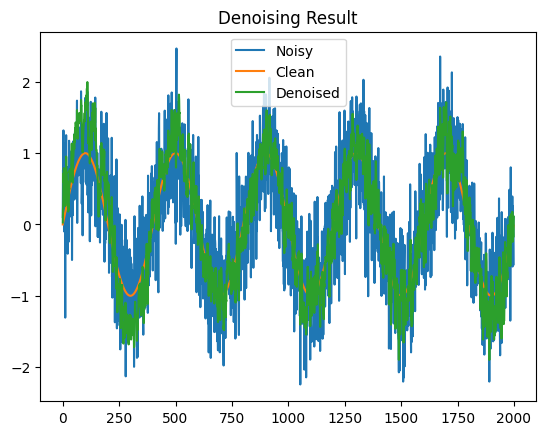

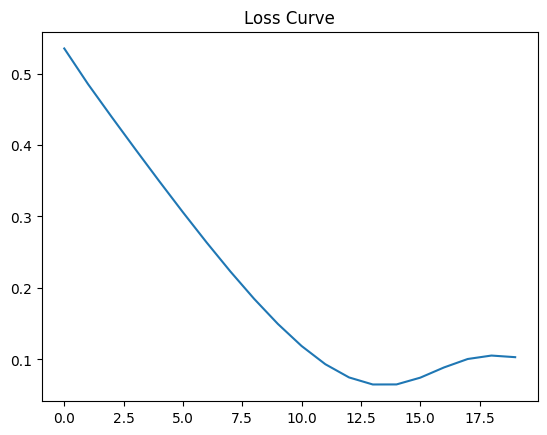

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

class TimeVaryingIIR(nn.Module):
    def __init__(self, order=2):
        super().__init__()
        self.order = order

        self.b_net = nn.Sequential(
            nn.Linear(1, 32),
            nn.ReLU(),
            nn.Linear(32, order + 1)
        )

        self.a_net = nn.Sequential(
            nn.Linear(1, 32),
            nn.ReLU(),
            nn.Linear(32, order)
        )

    def forward(self, x):
        B, T = x.shape
        y = torch.zeros_like(x)

        x_past = torch.zeros(B, self.order)
        y_past = torch.zeros(B, self.order)

        for t in range(T):
            t_norm = torch.full((B, 1), t / T)

            b = self.b_net(t_norm)
            a = torch.tanh(self.a_net(t_norm))

            x_t = x[:, t].unsqueeze(1)

            ff = b[:, 0:1] * x_t
            for i in range(self.order):
                ff += b[:, i+1:i+2] * x_past[:, i:i+1]

            fb = torch.zeros_like(ff)
            for i in range(self.order):
                fb += a[:, i:i+1] * y_past[:, i:i+1]

            y_t = ff - fb
            y[:, t] = y_t.squeeze(1)

            x_past = torch.cat([x_t, x_past[:, :-1]], dim=1)
            y_past = torch.cat([y_t, y_past[:, :-1]], dim=1)

        return y


# Generate signal
T = 2000
t = torch.linspace(0, 1, T)

clean = torch.sin(2 * 3.14 * 5 * t)
noise = 0.5 * torch.randn(T)
noisy = clean + noise

clean = clean.unsqueeze(0)
noisy = noisy.unsqueeze(0)

# Train
model = TimeVaryingIIR()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

losses = []

for epoch in range(20):
    optimizer.zero_grad()
    output = model(noisy)
    loss = loss_fn(output, clean)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

# Plot 1
plt.figure()
plt.plot(noisy.squeeze(), label="Noisy")
plt.plot(clean.squeeze(), label="Clean")
plt.plot(output.detach().squeeze(), label="Denoised")
plt.legend()
plt.title("Denoising Result")
plt.show()

# Plot 2
plt.figure()
plt.plot(losses)
plt.title("Loss Curve")
plt.show()